In [15]:
# ── Setup (Colab) ─────────────────────────────────────────────────────────────
import os, sys, math, random, json, pathlib
import numpy as np
import torch
import matplotlib.pyplot as plt

IN_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')

if IN_COLAB:
    if not os.path.exists('ufc-easytpp'):
        os.system('git clone https://github.com/hugoramos/ufc-easytpp.git')
    else:
        # garante que o Colab use a versao mais recente do repo (codigo do modelo)
        os.system('git -C ufc-easytpp reset --hard -q && git -C ufc-easytpp pull -q')

    # Aplica correção de _normalize_timestamps (Opção A: no-op que preserva timestamps)
    hothp_path = 'ufc-easytpp/easy_tpp/model/torch_model/torch_hothp.py'
    with open(hothp_path, 'r') as f:
        code = f.read()

    OLD = '''    def _normalize_timestamps(self, time_seqs):
        """Map raw timestamps so that the mean inter-event gap is ~1.0.

        Uses prefix-only normalization: event i is divided by the mean gap
        of events 0..i-1, so no future information leaks into position i.

        For position 0: t_shifted[0] == 0 always, divisor = 1 (irrelevant).
        For position i >= 1: divisor = mean(diffs[0..i-1])
                           = cumsum(diffs)[i-1] / i
        """
        B, T = time_seqs.shape
        # Use first event as reference — causally valid and equal to min for sorted seqs.
        t_shifted = time_seqs - time_seqs[:, :1]

        if T <= 1:
            return t_shifted

        diffs = t_shifted[:, 1:] - t_shifted[:, :-1]          # [B, T-1]
        cumsum = torch.cumsum(diffs, dim=-1)                    # [B, T-1]
        counts = torch.arange(1, T, device=time_seqs.device,
                               dtype=time_seqs.dtype).unsqueeze(0)  # [1, T-1]
        prefix_mean = cumsum / counts                           # [B, T-1]

        # divisor[0] = 1.0 (t_shifted[:,0] is always 0); divisor[i] = prefix_mean[i-1]
        ones = torch.ones(B, 1, device=time_seqs.device, dtype=time_seqs.dtype)
        divisor = torch.cat([ones, prefix_mean], dim=-1).clamp(min=1e-6)  # [B, T]

        return t_shifted / divisor'''

    NEW = '''    def _normalize_timestamps(self, time_seqs):
        """Pass through timestamps already normalized by to_tensors (mean gap = 1.0).

        The upstream pipeline (to_tensors) already divides all inter-event gaps
        by their sequence-level mean, so time_seqs arrives with mean gap ~1.0.
        The previous prefix-mean divisor algebraically cancelled to [0,1,2,...,T-1],
        destroying temporal information. This version preserves the structure.
        """
        return time_seqs - time_seqs[:, :1]'''

    if OLD in code:
        code = code.replace(OLD, NEW)
        with open(hothp_path, 'w') as f:
            f.write(code)
        print('✓ Correção aplicada em torch_hothp.py')
    elif 'return time_seqs - time_seqs[:, :1]' in code:
        print('✓ Correção já estava aplicada')
    else:
        print('⚠ Padrão não encontrado — verifique torch_hothp.py manualmente')

    # Fix de importação do __init__
    init_path = 'ufc-easytpp/easy_tpp/model/__init__.py'
    with open(init_path, 'w') as f:
        f.write("""from easy_tpp.model.torch_model.torch_basemodel import TorchBaseModel
from easy_tpp.model.torch_model.torch_thp import THP as TorchTHP
from easy_tpp.model.torch_model.torch_nhp import NHP as TorchNHP
from easy_tpp.model.torch_model.torch_rothp import RoTHP as TorchRoTHP
from easy_tpp.model.torch_model.torch_hothp import HoTHP as TorchHoTHP
""")

    sys.path.insert(0, os.path.abspath('ufc-easytpp'))
    os.system('pip install omegaconf -q')
else:
    ROOT = os.path.abspath('..')
    if ROOT not in sys.path:
        sys.path.insert(0, ROOT)

# Diretório de checkpoints
CKPT_DIR = pathlib.Path('checkpoints')
CKPT_DIR.mkdir(exist_ok=True)

print('✓ Setup concluído')

✓ Correção já estava aplicada
✓ Setup concluído


In [16]:
# ── Imports do easy_tpp ───────────────────────────────────────────────────────
import easy_tpp.model.torch_model.torch_baselayer as baselayer

def _attention(query, key, value, mask=None, dropout=None):
    d_k = query.size(-1)
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        if mask.dim() == 3:
            mask = mask.unsqueeze(1)
        scores = scores.masked_fill(mask > 0, -1e4)
    p = torch.softmax(scores, dim=-1)
    if dropout is not None:
        p = dropout(p)
    return torch.matmul(p, value), p

baselayer.attention = _attention

import easy_tpp.model.torch_model.torch_rothp as rothp_module
rothp_module.attention = _attention

from easy_tpp.config_factory.model_config import ModelConfig
from easy_tpp.model.torch_model.torch_nhp import NHP
from easy_tpp.model.torch_model.torch_thp import THP
from easy_tpp.model.torch_model.torch_rothp import RoTHP
from easy_tpp.model.torch_model.torch_hothp import HoTHP
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

CORES = {
    'NHP':   '#55A868',
    'THP':   '#8172B2',
    'RoTHP': '#4C72B0',
    'HoTHP': '#C44E52',
}

MODELOS = [
    ('NHP',   NHP),
    ('THP',   THP),
    ('RoTHP', RoTHP),
    ('HoTHP', HoTHP),
]

# Offset de seed por modelo, fixo (substitui hash(model_name), que e nao-deterministico
# entre execucoes por causa do PYTHONHASHSEED aleatorio do Python).
MODEL_SEED_OFFSET = {'NHP': 11, 'THP': 23, 'RoTHP': 37, 'HoTHP': 51}

print(f'Device: {device}')
print('Imports OK')

Device: cuda
Imports OK


In [17]:
# ── Configurações ────────────────────────────────────────────────────────────
TRAIN_LEN      = 50        # eventos no treino
EXTRAP_FACTORS = [1, 2, 5, 10]
N_SEEDS        = 10
EPOCHS         = 300
PATIENCE       = 30
NUM_TYPES      = 2
PAD_ID         = NUM_TYPES

REGIMES = {
    'Decaimento lento  (β=0.025)': dict(
        mu    = np.array([0.4, 0.4]),
        alpha = np.array([[0.12, 0.08], [0.08, 0.12]]),
        beta  = 0.025,
    ),
    'Decaimento rápido (β=0.50)': dict(
        mu    = np.array([0.4, 0.4]),
        alpha = np.array([[0.12, 0.08], [0.08, 0.12]]),
        beta  = 0.50,
    ),
}

LR_POR_MODELO = {
    'NHP':   1e-3,
    'THP':   1e-3,
    'RoTHP': 1e-3,
    'HoTHP': 5e-4,
}

def make_config():
    return ModelConfig(**{
        'hidden_size': 32, 'num_layers': 2, 'num_heads': 2, 'dropout_rate': 0.1,
        'num_event_types': NUM_TYPES, 'num_event_types_pad': NUM_TYPES + 1,
        'event_pad_index': PAD_ID, 'time_emb_size': 32, 'use_ln': True,
        'gpu': 0 if torch.cuda.is_available() else -1,
        'model_id': 'Val',
        'model_specs': {},
        'thinning': {'num_sample': 1, 'num_exp': 500, 'over_sample_rate': 5.0,
                     'patience_counter': 5, 'num_samples_boundary': 5,
                     'dtime_max': 5.0, 'num_step_gen': 1},
        'loss_integral_num_sample_per_step': 20,
        'use_mc_samples': False,
    })

print(f'TRAIN_LEN={TRAIN_LEN}, fatores={EXTRAP_FACTORS}, seeds={N_SEEDS}')

TRAIN_LEN=50, fatores=[1, 2, 5, 10], seeds=10


In [18]:
# ── Funções auxiliares ───────────────────────────────────────────────────────

def simulate_hawkes(rng, mu, alpha, beta, horizon, min_ev, max_ev):
    for _ in range(200):
        events, t = [], 0.0
        while t < horizon and len(events) < max_ev:
            lam = mu.copy()
            for ti, ki in events:
                lam += alpha[:, ki] * np.exp(-beta * (t - ti))
            lam_bar = float(lam.sum())
            if lam_bar < 1e-9: break
            t += rng.exponential(1.0 / lam_bar)
            if t >= horizon: break
            cand = mu.copy()
            for ti, ki in events:
                cand += alpha[:, ki] * np.exp(-beta * (t - ti))
            if rng.uniform() <= cand.sum() / lam_bar:
                probs = cand / cand.sum()
                events.append((t, int(rng.choice(len(mu), p=probs))))
        if len(events) >= min_ev:
            return events[:max_ev]
    return events[:max_ev]


def to_tensors(seqs):
    out = []
    for seq in seqs:
        seq = sorted(seq, key=lambda x: x[0])
        t = torch.tensor([x[0] for x in seq], dtype=torch.float32)
        k = torch.tensor([x[1] for x in seq], dtype=torch.long)
        d = torch.zeros_like(t)
        d[1:] = t[1:] - t[:-1]
        mg = d[1:].mean().clamp(min=1e-6)
        t = (t - t[0]) / mg
        d = d / mg
        out.append({'time_seqs': t, 'time_delta_seqs': d, 'type_seqs': k})
    return out


def collate(batch, pad_id=PAD_ID):
    B = len(batch)
    L = max(len(x['time_seqs']) for x in batch)
    t_pad = torch.zeros(B, L)
    d_pad = torch.zeros(B, L)
    k_pad = torch.full((B, L), pad_id, dtype=torch.long)
    npm   = torch.zeros(B, L)
    causal = torch.triu(torch.ones(L, L, dtype=torch.bool), diagonal=1)
    attn   = torch.ones(B, L, L, dtype=torch.bool)
    for i, item in enumerate(batch):
        sl = len(item['time_seqs'])
        t_pad[i, :sl] = item['time_seqs']
        d_pad[i, :sl] = item['time_delta_seqs']
        k_pad[i, :sl] = item['type_seqs']
        npm[i, :sl] = 1.0
        m = causal.clone()
        m[:, sl:] = True; m[sl:, :] = True
        attn[i] = m
    return t_pad, d_pad, k_pad, npm, attn


def make_loader(data, bs, shuffle=False, seed=None):
    g = None
    if shuffle and seed is not None:
        g = torch.Generator(); g.manual_seed(seed)
    return DataLoader(data, batch_size=min(bs, len(data)), shuffle=shuffle,
                      collate_fn=collate, generator=g)


def eval_nll(model, dl):
    model.eval()
    total_l = total_n = 0
    with torch.no_grad():
        for batch in dl:
            batch = [t.to(device) for t in batch]
            l, n = model.loglike_loss(batch)
            total_l += l.item(); total_n += n
    return total_l / (total_n + 1e-9)


def eval_prediction(model, dl):
    """Avalia RMSE do inter-event time e Accuracy do tipo do evento.

    Usa predict_one_step_at_every_event (thinning) para obter
    predições de dt e tipo em cada posição da sequência.
    """
    model.eval()
    all_dt_err_sq = []
    all_type_correct = []
    all_count = []
    with torch.no_grad():
        for batch in dl:
            batch_dev = [t.to(device) for t in batch]
            time_seqs, time_delta_seqs, type_seqs, batch_non_pad_mask, attention_mask = batch_dev

            try:
                dtimes_pred, types_pred = model.predict_one_step_at_every_event(batch_dev)
            except Exception:
                # Modelo pode não suportar predict_one_step
                return float('nan'), float('nan')

            # Labels: shift by 1 (predict next from current)
            dt_label = time_delta_seqs[:, 1:]  # [B, L-1]
            type_label = type_seqs[:, 1:]       # [B, L-1]
            mask = batch_non_pad_mask[:, 1:]    # [B, L-1]

            # Alinhar tamanhos (predict_one_step retorna seq_len = input_len - 1)
            min_len = min(dtimes_pred.size(1), dt_label.size(1))
            dtimes_pred = dtimes_pred[:, :min_len]
            types_pred = types_pred[:, :min_len]
            dt_label = dt_label[:, :min_len]
            type_label = type_label[:, :min_len]
            mask = mask[:, :min_len]

            dt_err_sq = ((dtimes_pred - dt_label) ** 2) * mask
            type_correct = ((types_pred == type_label).float()) * mask
            n = mask.sum().item()

            all_dt_err_sq.append(dt_err_sq.sum().item())
            all_type_correct.append(type_correct.sum().item())
            all_count.append(n)

    total_n = sum(all_count)
    if total_n == 0:
        return float('nan'), float('nan')
    rmse = math.sqrt(sum(all_dt_err_sq) / total_n)
    acc = sum(all_type_correct) / total_n
    return rmse, acc


def train_model(cls, train_dl, val_dl, lr, seed):
    set_seed(seed)
    config = make_config()
    m = cls(config).to(device)
    opt   = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=10, min_lr=1e-5)
    best_val, best_state, no_imp = float('inf'), None, 0
    for ep in range(EPOCHS):
        m.train()
        for batch in train_dl:
            batch = [t.to(device) for t in batch]
            opt.zero_grad()
            l, n = m.loglike_loss(batch)
            nll = l / (n + 1e-9)
            if not torch.isnan(nll):
                nll.backward()
                torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
                opt.step()
        v = eval_nll(m, val_dl)
        sched.step(v)
        if v < best_val - 1e-4:
            best_val = v
            best_state = {k: v2.cpu().clone() for k, v2 in m.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1
        if no_imp >= PATIENCE:
            break
    m.load_state_dict(best_state)
    return m, best_val


# ── Checkpoints ───────────────────────────────────────────────────────────────

def ckpt_path(model_name, regime_idx, seed_idx):
    """Retorna o caminho do checkpoint para um modelo/regime/seed."""
    return CKPT_DIR / f'{model_name}_regime{regime_idx}_seed{seed_idx}.pt'


def save_checkpoint(model, model_name, regime_idx, seed_idx, val_nll):
    path = ckpt_path(model_name, regime_idx, seed_idx)
    torch.save({
        'model_state_dict': {k: v.cpu() for k, v in model.state_dict().items()},
        'model_name': model_name,
        'val_nll': val_nll,
    }, path)
    return path


def load_checkpoint(cls, model_name, regime_idx, seed_idx):
    """Carrega checkpoint se existir. Retorna (model, val_nll) ou None."""
    path = ckpt_path(model_name, regime_idx, seed_idx)
    if not path.exists():
        return None
    ckpt = torch.load(path, map_location=device, weights_only=True)
    config = make_config()
    m = cls(config).to(device)
    try:
        m.load_state_dict(ckpt['model_state_dict'])
    except RuntimeError:
        # checkpoint de uma versao anterior do modelo (ex.: com log_time_scale) -> retreina
        return None
    return m, ckpt['val_nll']


# Se True, pula treino quando checkpoint existe
USE_CHECKPOINTS = True

print('Funções prontas.')

Funções prontas.


In [19]:
# ── Experimento principal ─────────────────────────────────────────────────────

METRIC_NAMES = ['nll', 'rmse', 'acc']
MODEL_NAMES = [name for name, _ in MODELOS]

# Cache incremental de métricas em disco. Estrutura:
#   metrics_cache[regime_name][str(seed_idx)][str(factor)][model_name] = {nll, rmse, acc}
# Permite retomar a execução sem reavaliar o que já foi computado (a avaliação,
# não o treino, é o gargalo: simulação de Hawkes em Python + thinning no RMSE/Acc).
METRICS_CACHE_PATH = CKPT_DIR / 'metrics_cache.json'

def _load_metrics_cache():
    if METRICS_CACHE_PATH.exists():
        with open(METRICS_CACHE_PATH) as fh:
            return json.load(fh)
    return {}

def _save_metrics_cache(cache):
    with open(METRICS_CACHE_PATH, 'w') as fh:
        json.dump(cache, fh, indent=2)

metrics_cache = _load_metrics_cache()

def _seed_complete(regime_name, seed_idx):
    """True se TODAS as métricas (todos fatores × modelos) deste seed já estão no cache."""
    rc = metrics_cache.get(regime_name, {}).get(str(seed_idx))
    if rc is None:
        return False
    for f in EXTRAP_FACTORS:
        fc = rc.get(str(f))
        if fc is None or any(mn not in fc for mn in MODEL_NAMES):
            return False
    return True

for regime_idx, (regime_name, proc) in enumerate(REGIMES.items()):
    print(f'\n{"="*70}')
    print(f'Regime: {regime_name}')
    print(f'{"="*70}')

    mu, alpha, beta = proc['mu'], proc['alpha'], proc['beta']
    horizon_train = max(50.0, TRAIN_LEN / mu.sum() * 3)

    for seed_idx in range(N_SEEDS):
        seed = 42 + seed_idx * 100

        # (1) Se as métricas deste seed já estão completas no cache, pula tudo.
        if _seed_complete(regime_name, seed_idx):
            print(f'  seed {seed_idx}: métricas já em cache — pulando')
            continue

        # (2) Verifica quais modelos vêm do checkpoint; só treina (e só gera
        #     treino/val) se algum modelo realmente precisar ser treinado.
        loaded_models = {}
        need_training = False
        for model_name, model_cls in MODELOS:
            loaded = load_checkpoint(model_cls, model_name, regime_idx, seed_idx) if USE_CHECKPOINTS else None
            loaded_models[model_name] = loaded
            if loaded is None:
                need_training = True

        if need_training:
            rng = np.random.default_rng(seed)
            raw_train = [simulate_hawkes(rng, mu, alpha, beta, horizon_train, 5, TRAIN_LEN)
                         for _ in range(400)]
            raw_val   = [simulate_hawkes(rng, mu, alpha, beta, horizon_train, 5, TRAIN_LEN)
                         for _ in range(100)]
            train_dl = make_loader(to_tensors(raw_train), 64, shuffle=True, seed=seed)
            val_dl   = make_loader(to_tensors(raw_val),   64)

        trained = {}
        for model_name, model_cls in MODELOS:
            loaded = loaded_models[model_name]
            if loaded is not None:
                model, val_nll = loaded
                print(f'  [{model_name}] seed {seed_idx}: carregado do checkpoint (val={val_nll:.4f})')
            else:
                lr = LR_POR_MODELO[model_name]
                model, val_nll = train_model(model_cls, train_dl, val_dl, lr=lr,
                                             seed=seed + MODEL_SEED_OFFSET[model_name])
                save_checkpoint(model, model_name, regime_idx, seed_idx, val_nll)
                print(f'  [{model_name}] seed {seed_idx}: treinado  (val={val_nll:.4f}) ✓ checkpoint salvo')
            trained[model_name] = model

        # (3) Avalia em cada fator de extrapolação, com cache por (seed, fator, modelo).
        #     RNG de teste dedicado por (seed, fator): os dados de teste ficam
        #     reproduzíveis e INDEPENDENTES de ter havido treino — pular o treino
        #     não altera mais o estado do RNG usado no teste.
        seed_cache = metrics_cache.setdefault(regime_name, {}).setdefault(str(seed_idx), {})
        for f in EXTRAP_FACTORS:
            factor_cache = seed_cache.setdefault(str(f), {})
            missing = [mn for mn in MODEL_NAMES if mn not in factor_cache]

            if not missing:
                row = [f'{mn}: NLL={factor_cache[mn]["nll"]:.4f} '
                       f'RMSE={factor_cache[mn]["rmse"]:.4f} '
                       f'Acc={factor_cache[mn]["acc"]:.3f} (cache)' for mn in MODEL_NAMES]
                print(f'    α={f:>2}x  ' + '  |  '.join(row))
                continue

            target_len = TRAIN_LEN * f
            horizon_test = max(horizon_train * f, horizon_train + 10)
            rng_test = np.random.default_rng([seed, f])
            raw_test = [simulate_hawkes(rng_test, mu, alpha, beta, horizon_test,
                                        TRAIN_LEN + 1, target_len)
                        for _ in range(200)]
            test_dl = make_loader(to_tensors(raw_test), 32)

            for model_name in missing:
                model = trained[model_name]
                nll_val = eval_nll(model, test_dl)
                rmse_val, acc_val = eval_prediction(model, test_dl)
                factor_cache[model_name] = {'nll': float(nll_val),
                                            'rmse': float(rmse_val),
                                            'acc': float(acc_val)}

            _save_metrics_cache(metrics_cache)  # persiste após cada fator
            row = [f'{mn}: NLL={factor_cache[mn]["nll"]:.4f} '
                   f'RMSE={factor_cache[mn]["rmse"]:.4f} '
                   f'Acc={factor_cache[mn]["acc"]:.3f}' for mn in MODEL_NAMES]
            print(f'    α={f:>2}x  ' + '  |  '.join(row))

# (4) Reconstrói all_results no formato esperado pelas células seguintes,
#     em ordem de seed, a partir do cache (robusto a execuções retomadas).
#     all_results[regime][factor][model_name][metric] = lista de valores por seed
all_results = {}
for regime_name in REGIMES:
    rdict = {f: {mn: {met: [] for met in METRIC_NAMES} for mn in MODEL_NAMES}
             for f in EXTRAP_FACTORS}
    for seed_idx in range(N_SEEDS):
        for f in EXTRAP_FACTORS:
            for mn in MODEL_NAMES:
                m = metrics_cache[regime_name][str(seed_idx)][str(f)][mn]
                for met in METRIC_NAMES:
                    rdict[f][mn][met].append(m[met])
    all_results[regime_name] = rdict

print('\n✓ Experimento concluído.')



Regime: Decaimento lento  (β=0.025)
  seed 0: métricas já em cache — pulando
  seed 1: métricas já em cache — pulando
  seed 2: métricas já em cache — pulando
  seed 3: métricas já em cache — pulando
  seed 4: métricas já em cache — pulando
  seed 5: métricas já em cache — pulando
  seed 6: métricas já em cache — pulando
  seed 7: métricas já em cache — pulando
  seed 8: métricas já em cache — pulando
  seed 9: métricas já em cache — pulando

Regime: Decaimento rápido (β=0.50)
  seed 0: métricas já em cache — pulando
  seed 1: métricas já em cache — pulando
  seed 2: métricas já em cache — pulando
  seed 3: métricas já em cache — pulando
  seed 4: métricas já em cache — pulando
  seed 5: métricas já em cache — pulando
  seed 6: métricas já em cache — pulando
  seed 7: métricas já em cache — pulando
  seed 8: métricas já em cache — pulando
  seed 9: métricas já em cache — pulando

✓ Experimento concluído.


In [20]:
# ── Salvar resultados em JSON (para reprodutibilidade) ────────────────────────

# Blindagem: se o runtime do Colab reiniciou e all_results não existe mais em
# memória, reconstrói a partir do cache em disco (checkpoints/metrics_cache.json)
# sem reavaliar nada. Se o cache também não existir, instrui a rodar a célula 4.
if 'all_results' not in globals():
    _cache_path = CKPT_DIR / 'metrics_cache.json'
    if _cache_path.exists():
        with open(_cache_path) as _fh:
            _mc = json.load(_fh)
        all_results = {}
        for _regime in REGIMES:
            _rdict = {f: {mn: {met: [] for met in METRIC_NAMES} for mn in MODEL_NAMES}
                      for f in EXTRAP_FACTORS}
            for _seed in range(N_SEEDS):
                for f in EXTRAP_FACTORS:
                    for mn in MODEL_NAMES:
                        _m = _mc[_regime][str(_seed)][str(f)][mn]
                        for met in METRIC_NAMES:
                            _rdict[f][mn][met].append(_m[met])
            all_results[_regime] = _rdict
        print('ℹ all_results reconstruído a partir de checkpoints/metrics_cache.json')
    else:
        raise RuntimeError(
            'all_results não existe e não há metrics_cache.json. '
            'Rode a célula "Experimento principal" (célula 4) primeiro.'
        )

def results_to_serializable(all_results):
    """Converte all_results para formato serializável em JSON."""
    out = {}
    for regime, factors in all_results.items():
        out[regime] = {}
        for f, models in factors.items():
            out[regime][str(f)] = {}
            for mn, metrics in models.items():
                out[regime][str(f)][mn] = {
                    met: [float(v) for v in vals] for met, vals in metrics.items()
                }
    return out

with open(CKPT_DIR / 'results.json', 'w') as f:
    json.dump(results_to_serializable(all_results), f, indent=2)
print(f'✓ Resultados salvos em {CKPT_DIR / "results.json"}')


✓ Resultados salvos em checkpoints/results.json


In [21]:
# ── Tabela resumo — NLL ──────────────────────────────────────────────────────

print('RESUMO — NLL médio ± desvio (n={} seeds)'.format(N_SEEDS))
print()

for regime_name, results in all_results.items():
    print(f'{regime_name}')
    header = f'  {"α":>4}'
    for mn in MODEL_NAMES:
        header += f'  {mn:>14}'
    print(header)
    print(f'  {"─"*4}' + f'  {"─"*14}' * len(MODEL_NAMES))
    for f in EXTRAP_FACTORS:
        row = f'  {f:>3}x'
        for mn in MODEL_NAMES:
            vals = np.array(results[f][mn]['nll'])
            row += f'  {vals.mean():.4f}±{vals.std():.4f}'
        print(row)
    print()

RESUMO — NLL médio ± desvio (n=10 seeds)

Decaimento lento  (β=0.025)
     α             NHP             THP           RoTHP           HoTHP
  ────  ──────────────  ──────────────  ──────────────  ──────────────
    1x  1.4702±0.0068  1.4754±0.0069  1.4986±0.0138  1.5445±0.0249
    2x  2.1972±0.1309  3.9257±1.5049  2.0069±0.2839  1.6086±0.0958
    5x  2.6671±0.2358  4.1274±1.8030  2.6418±0.5095  1.9433±0.3132
   10x  2.8169±0.2734  4.1989±2.1167  3.0014±0.6253  2.3640±0.6249

Decaimento rápido (β=0.50)
     α             NHP             THP           RoTHP           HoTHP
  ────  ──────────────  ──────────────  ──────────────  ──────────────
    1x  1.6630±0.0052  1.6767±0.0107  1.6809±0.0073  1.6892±0.0078
    2x  1.8331±0.1342  3.3915±0.7814  2.0386±0.2788  1.7012±0.0117
    5x  2.0575±0.2229  3.7608±1.0716  2.1463±0.3089  1.7399±0.0499
   10x  2.1532±0.2497  3.8966±1.5093  2.2753±0.3724  1.7743±0.0920



In [22]:
# ── Tabela resumo — RMSE ─────────────────────────────────────────────────────

print('RESUMO — RMSE médio ± desvio (n={} seeds)'.format(N_SEEDS))
print()

for regime_name, results in all_results.items():
    print(f'{regime_name}')
    header = f'  {"α":>4}'
    for mn in MODEL_NAMES:
        header += f'  {mn:>14}'
    print(header)
    print(f'  {"─"*4}' + f'  {"─"*14}' * len(MODEL_NAMES))
    for f in EXTRAP_FACTORS:
        row = f'  {f:>3}x'
        for mn in MODEL_NAMES:
            vals = np.array(results[f][mn]['rmse'])
            valid = vals[~np.isnan(vals)]
            if len(valid) > 0:
                row += f'  {valid.mean():.4f}±{valid.std():.4f}'
            else:
                row += f'  {"N/A":>14}'
        print(row)
    print()

RESUMO — RMSE médio ± desvio (n=10 seeds)

Decaimento lento  (β=0.025)
     α             NHP             THP           RoTHP           HoTHP
  ────  ──────────────  ──────────────  ──────────────  ──────────────
    1x  1.6589±0.0342  1.6384±0.0742  1.6080±0.0921  1.6078±0.1180
    2x  1.7395±0.1887  1.6925±0.0329  1.6782±0.0298  1.6972±0.0574
    5x  2.2525±0.1325  2.2634±0.0356  2.2264±0.0327  2.1688±0.0158
   10x  2.8040±0.1031  2.8180±0.0353  2.7747±0.0190  2.7139±0.0246

Decaimento rápido (β=0.50)
     α             NHP             THP           RoTHP           HoTHP
  ────  ──────────────  ──────────────  ──────────────  ──────────────
    1x  1.5438±0.0200  1.5843±0.0822  1.5486±0.0753  1.5147±0.0597
    2x  1.5489±0.0514  1.5031±0.0461  1.4728±0.0396  1.4964±0.0722
    5x  1.5792±0.1979  1.4626±0.0371  1.4293±0.0238  1.4721±0.0751
   10x  1.5490±0.2011  1.4352±0.0290  1.4074±0.0212  1.4566±0.0859



In [23]:
# ── Tabela resumo — Accuracy ─────────────────────────────────────────────────

print('RESUMO — Accuracy média ± desvio (n={} seeds)'.format(N_SEEDS))
print()

for regime_name, results in all_results.items():
    print(f'{regime_name}')
    header = f'  {"α":>4}'
    for mn in MODEL_NAMES:
        header += f'  {mn:>14}'
    print(header)
    print(f'  {"─"*4}' + f'  {"─"*14}' * len(MODEL_NAMES))
    for f in EXTRAP_FACTORS:
        row = f'  {f:>3}x'
        for mn in MODEL_NAMES:
            vals = np.array(results[f][mn]['acc'])
            valid = vals[~np.isnan(vals)]
            if len(valid) > 0:
                row += f'  {valid.mean():.4f}±{valid.std():.4f}'
            else:
                row += f'  {"N/A":>14}'
        print(row)
    print()

RESUMO — Accuracy média ± desvio (n=10 seeds)

Decaimento lento  (β=0.025)
     α             NHP             THP           RoTHP           HoTHP
  ────  ──────────────  ──────────────  ──────────────  ──────────────
    1x  0.5078±0.0066  0.5113±0.0033  0.5054±0.0079  0.5044±0.0066
    2x  0.5045±0.0039  0.5055±0.0060  0.5018±0.0037  0.5061±0.0042
    5x  0.5017±0.0029  0.5006±0.0027  0.5002±0.0023  0.5023±0.0027
   10x  0.5009±0.0019  0.5017±0.0018  0.5006±0.0017  0.5014±0.0023

Decaimento rápido (β=0.50)
     α             NHP             THP           RoTHP           HoTHP
  ────  ──────────────  ──────────────  ──────────────  ──────────────
    1x  0.5082±0.0037  0.5005±0.0057  0.5057±0.0056  0.4998±0.0042
    2x  0.5096±0.0036  0.5042±0.0051  0.5006±0.0030  0.5005±0.0053
    5x  0.5064±0.0040  0.5007±0.0030  0.5008±0.0028  0.5016±0.0033
   10x  0.5067±0.0033  0.5008±0.0017  0.5013±0.0025  0.5012±0.0016



In [24]:
# ── Significância estatística: Wilcoxon pareado (HoTHP vs baselines) ─────────
# Hipótese direcional H1: HoTHP tem NLL MENOR que o baseline (extrapola melhor).
# Pareamos por seed: a mesma seed gera o mesmo treino/val/teste para todos os modelos.
# Obs.: com n seeds, o menor p possivel (1-caudal) do Wilcoxon e 1/2^n.
#       n=10 -> menor p = 1/1024 ~= 0.001 (folga confortavel para alpha=0.05).
from scipy.stats import wilcoxon

BASELINES = ['NHP', 'THP', 'RoTHP']
print(f'Wilcoxon signed-rank pareado, 1-caudal (H1: NLL_HoTHP < NLL_baseline), n={N_SEEDS} seeds')
print(f'menor p possivel (1-caudal) = 1/2^{N_SEEDS} = {1/2**N_SEEDS:.5f}')
print('Delta = NLL_HoTHP - NLL_baseline  (negativo = HoTHP melhor);  (*) p < 0.05\n')

for regime_name, results in all_results.items():
    print(f'== {regime_name} ==')
    for f in EXTRAP_FACTORS:
        ho = np.array(results[f]['HoTHP']['nll'])
        cells_out = []
        for b in BASELINES:
            bl = np.array(results[f][b]['nll'])
            dnll = float((ho - bl).mean())
            try:
                _, p = wilcoxon(ho, bl, alternative='less')
            except ValueError:
                p = float('nan')
            sig = '*' if (p == p and p < 0.05) else ' '
            cells_out.append(f'vs {b:<5} d={dnll:+.3f} p={p:.4f}{sig}')
        print(f'  a={f:>2}x  ' + '  |  '.join(cells_out))
    print()


Wilcoxon signed-rank pareado, 1-caudal (H1: NLL_HoTHP < NLL_baseline), n=10 seeds
menor p possivel (1-caudal) = 1/2^10 = 0.00098
Delta = NLL_HoTHP - NLL_baseline  (negativo = HoTHP melhor);  (*) p < 0.05

== Decaimento lento  (β=0.025) ==
  a= 1x  vs NHP   d=+0.074 p=1.0000   |  vs THP   d=+0.069 p=1.0000   |  vs RoTHP d=+0.046 p=1.0000 
  a= 2x  vs NHP   d=-0.589 p=0.0010*  |  vs THP   d=-2.317 p=0.0010*  |  vs RoTHP d=-0.398 p=0.0010*
  a= 5x  vs NHP   d=-0.724 p=0.0010*  |  vs THP   d=-2.184 p=0.0010*  |  vs RoTHP d=-0.698 p=0.0049*
  a=10x  vs NHP   d=-0.453 p=0.0420*  |  vs THP   d=-1.835 p=0.0049*  |  vs RoTHP d=-0.637 p=0.0244*

== Decaimento rápido (β=0.50) ==
  a= 1x  vs NHP   d=+0.026 p=1.0000   |  vs THP   d=+0.013 p=0.9902   |  vs RoTHP d=+0.008 p=0.9951 
  a= 2x  vs NHP   d=-0.132 p=0.0020*  |  vs THP   d=-1.690 p=0.0010*  |  vs RoTHP d=-0.337 p=0.0010*
  a= 5x  vs NHP   d=-0.318 p=0.0010*  |  vs THP   d=-2.021 p=0.0010*  |  vs RoTHP d=-0.406 p=0.0010*
  a=10x  vs NHP   d=

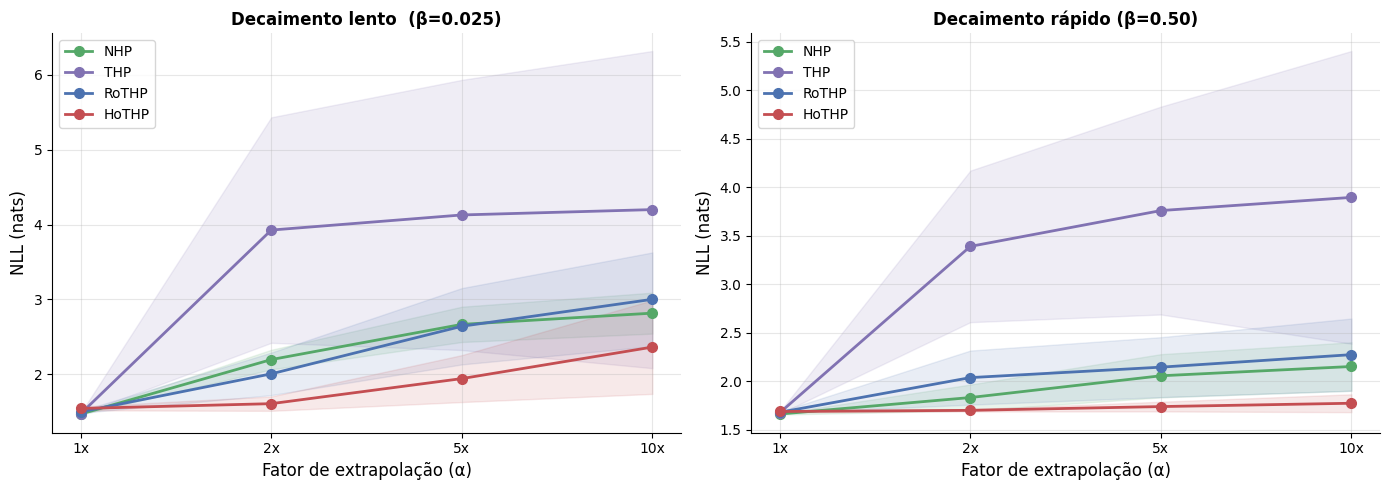

In [25]:
# ── Gráfico: NLL por fator de extrapolação ───────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(EXTRAP_FACTORS))
xlabels = [f'{f}x' for f in EXTRAP_FACTORS]

for ax, (regime_name, results) in zip(axes, all_results.items()):
    for mn in MODEL_NAMES:
        means = np.array([np.mean(results[f][mn]['nll']) for f in EXTRAP_FACTORS])
        stds  = np.array([np.std(results[f][mn]['nll'])  for f in EXTRAP_FACTORS])
        ax.plot(x, means, 'o-', color=CORES[mn], lw=2, ms=7, label=mn)
        ax.fill_between(x, means - stds, means + stds, color=CORES[mn], alpha=0.12)

    ax.set_xticks(x)
    ax.set_xticklabels(xlabels)
    ax.set_xlabel('Fator de extrapolação (α)', fontsize=12)
    ax.set_ylabel('NLL (nats)', fontsize=12)
    ax.set_title(regime_name, fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# fig.suptitle(f'NLL — Train Short, Test Long (TRAIN_LEN={TRAIN_LEN}, n={N_SEEDS} seeds)',
            #  fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('validacao_nll.png', dpi=150, bbox_inches='tight')
plt.show()

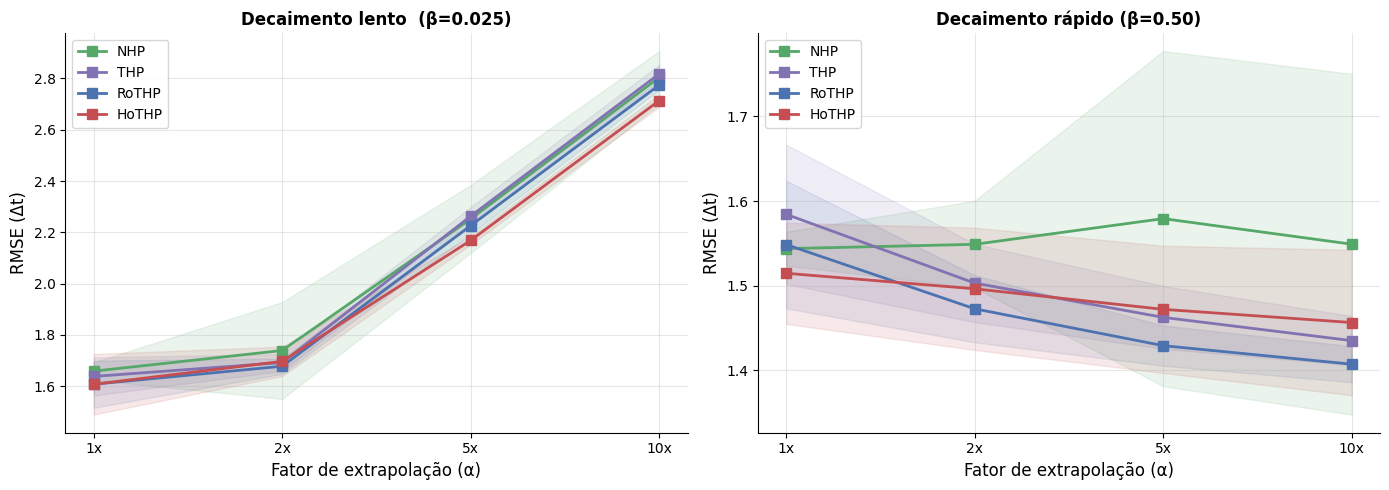

In [26]:
# ── Gráfico: RMSE por fator de extrapolação ──────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (regime_name, results) in zip(axes, all_results.items()):
    for mn in MODEL_NAMES:
        raw = [results[f][mn]['rmse'] for f in EXTRAP_FACTORS]
        means = np.array([np.nanmean(v) for v in raw])
        stds  = np.array([np.nanstd(v) for v in raw])
        if np.all(np.isnan(means)):
            continue
        ax.plot(x, means, 's-', color=CORES[mn], lw=2, ms=7, label=mn)
        ax.fill_between(x, means - stds, means + stds, color=CORES[mn], alpha=0.12)

    ax.set_xticks(x)
    ax.set_xticklabels(xlabels)
    ax.set_xlabel('Fator de extrapolação (α)', fontsize=12)
    ax.set_ylabel('RMSE (Δt)', fontsize=12)
    ax.set_title(regime_name, fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# fig.suptitle(f'RMSE — Train Short, Test Long (TRAIN_LEN={TRAIN_LEN}, n={N_SEEDS} seeds)',
            #  fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('validacao_rmse.png', dpi=150, bbox_inches='tight')
plt.show()

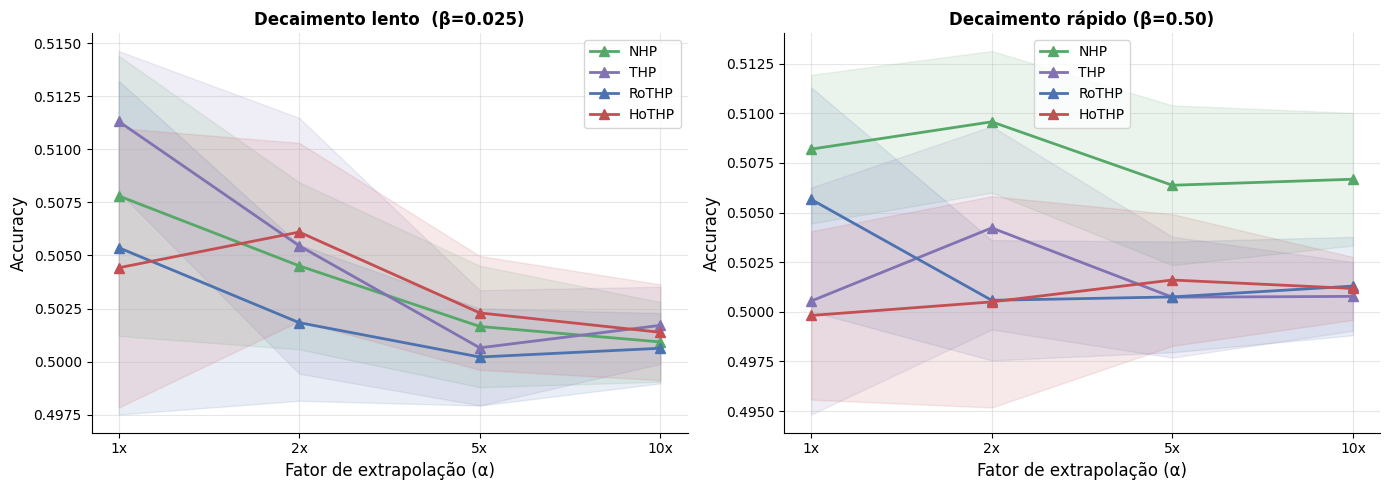

In [27]:
# ── Gráfico: Accuracy por fator de extrapolação ──────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (regime_name, results) in zip(axes, all_results.items()):
    for mn in MODEL_NAMES:
        raw = [results[f][mn]['acc'] for f in EXTRAP_FACTORS]
        means = np.array([np.nanmean(v) for v in raw])
        stds  = np.array([np.nanstd(v) for v in raw])
        if np.all(np.isnan(means)):
            continue
        ax.plot(x, means, '^-', color=CORES[mn], lw=2, ms=7, label=mn)
        ax.fill_between(x, means - stds, means + stds, color=CORES[mn], alpha=0.12)

    ax.set_xticks(x)
    ax.set_xticklabels(xlabels)
    ax.set_xlabel('Fator de extrapolação (α)', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title(regime_name, fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# fig.suptitle(f'Accuracy — Train Short, Test Long (TRAIN_LEN={TRAIN_LEN}, n={N_SEEDS} seeds)',
            #  fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('validacao_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

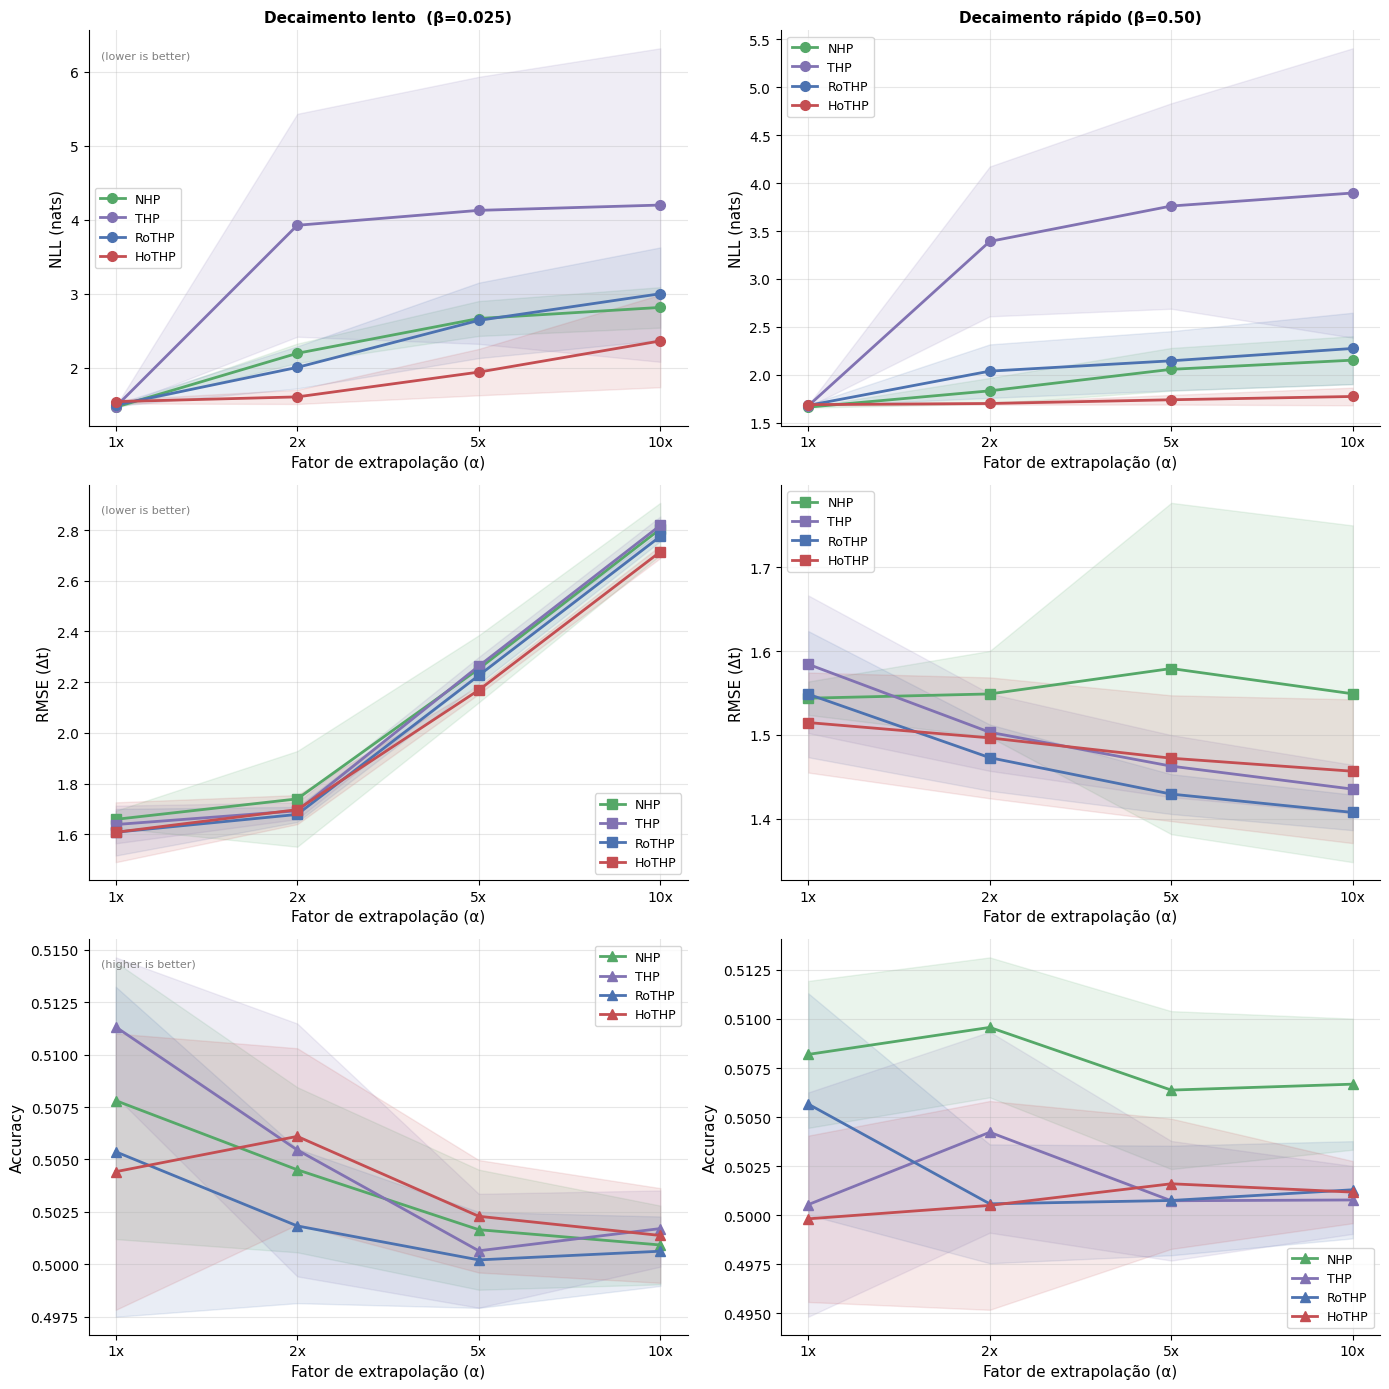

In [29]:
# ── Gráfico consolidado: 3 métricas × 2 regimes ─────────────────────────────

fig, axes = plt.subplots(3, 2, figsize=(14, 14))

metric_info = [
    ('nll',  'NLL (nats)',  'o-', 'lower is better'),
    ('rmse', 'RMSE (Δt)',  's-', 'lower is better'),
    ('acc',  'Accuracy',   '^-', 'higher is better'),
]

for row, (met_key, ylabel, marker, note) in enumerate(metric_info):
    for col, (regime_name, results) in enumerate(all_results.items()):
        ax = axes[row, col]
        for mn in MODEL_NAMES:
            raw = [results[f][mn][met_key] for f in EXTRAP_FACTORS]
            means = np.array([np.nanmean(v) for v in raw])
            stds  = np.array([np.nanstd(v) for v in raw])
            if np.all(np.isnan(means)):
                continue
            ax.plot(x, means, marker, color=CORES[mn], lw=2, ms=7, label=mn)
            ax.fill_between(x, means - stds, means + stds, color=CORES[mn], alpha=0.12)

        ax.set_xticks(x)
        ax.set_xticklabels(xlabels)
        ax.set_xlabel('Fator de extrapolação (α)', fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        title = regime_name if row == 0 else ''
        if title:
            ax.set_title(title, fontsize=11, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if col == 0:
            ax.annotate(f'({note})', xy=(0.02, 0.95), xycoords='axes fraction',
                        fontsize=8, color='gray', va='top')

# fig.suptitle(f'Validação pós-correção — Train Short, Test Long\n'
            #  f'TRAIN_LEN={TRAIN_LEN}, n={N_SEEDS} seeds, {len(MODEL_NAMES)} modelos',
            #  fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('validacao_consolidado.png', dpi=150, bbox_inches='tight')
plt.show()